In [25]:
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.quantum_info import Operator

from tqdm import tqdm

In [26]:
from pmns import PMNS_matrix_4x4
from hamiltonians import U1_omega_Omega, theta_ij, J_ij
from hamiltonians import nunu_interaction_p, nunu_interaction, nunu_interaction_s
from helpers import get_target_state, swap_correction_order_bp, get_interaction_pair_index

from backend import get_sampler
from transpile import produce_transpile_args

import sys

sys.path.append('../utils/')

from JobResult import JobResult

In [27]:
# backend settings

sampler, backend, config = get_sampler('aer')
N = 4

# trotter settings
# set in natural units here
# conversion to mu^-1 happens later automatically
dt = 5
T_max = 20

# run settings

shots = 8192

Using Noiseless Aer


In [28]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####
theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

dt = dt / mu
T_max = T_max / mu
steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

In [29]:
def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt, interact_func = nunu_interaction, post_fix_func = None):
    """
    interact_func: function for the interaction, for example, nunu_interaction or nunu_interaction_p
    post_fix_func: function to update the order and base_pattern after interaction, given by (order, base_pattern, i, j) -> (new_order, new_base_pattern)
    """
    for i, j in pair_indices:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E, mu, N) * dt

        print("current order and base pattern:", order, base_pattern)
        print("Simple indexes:", i, j)
        print(f"Applying interaction for pair ({order[i]}, {order[j]}) with alpha_ij = {alpha_ij:.4f}")
        interact_func(qc, q, alpha_ij)
        order, base_pattern = post_fix_func(order, base_pattern, i, j) if post_fix_func else (order, base_pattern)
        
    print("Final order and base pattern after interaction:", order, base_pattern)

    return order, base_pattern


In [ ]:
# initialization for run


def init_order_and_base_pattern():
    # generate initial pattern
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e

    # order map
    order = [i for i in range(N)]

    return order, base_pattern

# interaction sequence
pair_indices = get_interaction_pair_index(N, method = 'default')

# collect data
probabilities = []

In [ ]:
for t in times:

    order, base_pattern = init_order_and_base_pattern()
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # Trotterization
    Trotter = int(t / dt)
    for _ in range(Trotter):
        for i in range(N):
            qc.append(U1_omega_Omega(dt, omega, Omega), [2*i, 2*i+1])

        # order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
        #                                              interact_func=nunu_interaction_p,
        #                                              post_fix_func=swap_correction_order_bp)
        order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
                                                     interact_func=nunu_interaction,
                                                     post_fix_func=None)

    # Apply U_PMNS
    U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")

    # Measurement
    qc.measure(range(2 * N), reversed((range(2 * N))))

    transpile_args = produce_transpile_args(config=config)

    tqc = transpile(qc, backend, **transpile_args)

    job = JobResult(sampler)

    job.run(tqc, {'shots': shots})

    counts = job.get_counts()

    target_state = get_target_state(base_pattern)

    prob = counts.get(target_state, 0) / shots
    print("Measurement counts:", counts)
    probabilities.append(prob)


Measurement counts: {'00010010': 8192}
current order and base pattern: [0, 1, 2, 3] ['E', 'M', 'E', 'T']
Simple indexes: 0 1
Applying interaction for pair (0, 1) with alpha_ij = 0.0141
current order and base pattern: [1, 0, 2, 3] ['M', 'E', 'E', 'T']
Simple indexes: 1 2
Applying interaction for pair (0, 2) with alpha_ij = 0.0561
current order and base pattern: [1, 2, 0, 3] ['M', 'E', 'E', 'T']
Simple indexes: 2 3
Applying interaction for pair (0, 3) with alpha_ij = 0.1250
current order and base pattern: [1, 2, 3, 0] ['M', 'E', 'T', 'E']
Simple indexes: 0 1
Applying interaction for pair (1, 2) with alpha_ij = 0.0141
current order and base pattern: [2, 1, 3, 0] ['E', 'M', 'T', 'E']
Simple indexes: 1 2
Applying interaction for pair (1, 3) with alpha_ij = 0.0561
current order and base pattern: [2, 3, 1, 0] ['E', 'T', 'M', 'E']
Simple indexes: 0 1
Applying interaction for pair (2, 3) with alpha_ij = 0.0141
Final order and base pattern after interaction: [3, 2, 1, 0] ['T', 'E', 'M', 'E']
Mea

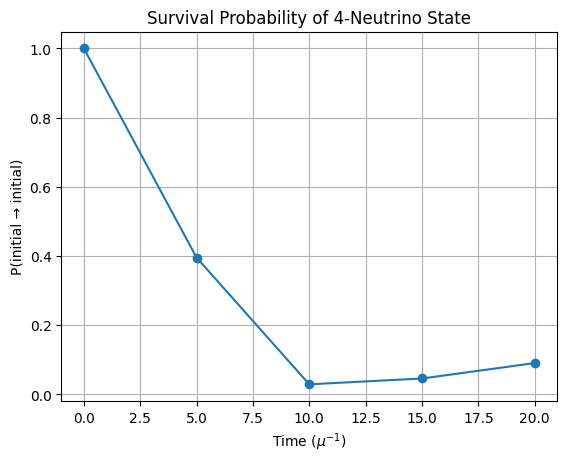

In [32]:
# Plot
plt.plot(times * mu, probabilities, marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
plt.savefig("survi_prob_{0}_nu.png".format(N))